# Lab 11

## Section 1: PyTorch 



## Import Torch

In [5]:
pip install torch

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/113.8 MB 5.6 MB/s eta 0:00:21
    --------------------------------------- 1.6/113.8 MB 4.9 MB/s eta 0:00:23
    --------------------------------------- 2.4/113.8 MB 4.2 MB/s eta 0:00:27
    --------------------------------------- 2.6/113.8 MB 4.0 MB/s eta 0:00:28
   - -------------------------------------- 2.9/113.8 MB 3.3 MB/s eta 0:00:34
   - -------------------------------------- 2.9/113.8 MB 3.3 MB/s eta 0:00:34
   - -------------------------------------- 3.1/113.8 MB 2.5 MB/s eta 0:00:45
   - -------------------------------------- 3.4/113.8 MB 2.2 MB/s eta 0:00:50
   - -------------------------------------- 3.4/113.8 MB 2.2 MB/s eta 0:00:50
   - -------------------------------------- 3.7/113.8 MB 1.8 MB/s eta 0:01:03
   - -------------------------------------- 3.7/113.8 MB 1.8 MB/s eta 0:01:03
   - ----

In [22]:
pip install torchvision

   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.3 MB ? eta -:--:--
   ------- -------------------------------- 0.8/4.3 MB 2.1 MB/s eta 0:00:02
   --------- ------------------------------ 1.0/4.3 MB 2.0 MB/s eta 0:00:02
   ------------ --------------------------- 1.3/4.3 MB 2.0 MB/s eta 0:00:02
   -------------- ------------------------- 1.6/4.3 MB 1.8 MB/s eta 0:00:02
   ----------------- ---------------------- 1.8/4.3 MB 1.7 MB/s eta 0:00:02
   ------------------- -------------------- 2.1/4.3 MB 1.7 MB/s eta 0:00:02
   ------------------- -------------------- 2.1/4.3 MB 1.7 MB/s eta 0:00:02
   --------------------- ------------------ 2.4/4.3 MB 1.3 MB/s eta 0:00:02
   --------------------- ------------------ 2.4/4.3 MB 1.3 MB/s eta 0:00:02
   --------------------- ------------------ 2.4/4.3 MB 1.3 MB/s eta 0:00:02
   ------------------------ --------------- 2.6/4.3 MB 1.1 MB/s eta 0:00:02
   -----------------------

In [3]:
import torch
import torch.nn as n
import torch.optim as optim


### Task 1: GPU/Device Agnostic Code
**Goal:** Write code that runs on CPU, CUDA, or MPS (Mac) automatically.


In [4]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')


sample_input = torch.randn(1, 10).to(device)
type(sample_input)

Using device: cpu


torch.Tensor

In [9]:

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

CUDA available: False
CUDA version: None
Device count: 0


## Section 2: MNIST Project 
Step 1: What is MNIST & Downloading Data

Concept: MNIST is the "Hello World" of Machine Learning. It contains 70,000 images of handwritten digits (0-9).

The Goal: Teach the computer to look at a grid of pixels and say "That is a 7".

The Data: Each image is grayscale and exactly 28×28


In [11]:
from torchvision import datasets
from torchvision.transforms import ToTensor

In [12]:
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

# transform=ToTensor() converts the image (0-255) to a Torch Tensor (0.0-1.0)

In [15]:
# Do for Testing
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

## Visualizing One Image & Understanding Shapes

In [17]:
len(training_data)

60000

In [19]:
len(test_data)

10000

In [21]:
img, label = training_data[34]

In [23]:
img.shape

torch.Size([1, 28, 28])

In [25]:
img

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [27]:
img.squeeze()

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

## Display one Image in MatplotLib

In [29]:
import matplotlib.pyplot as plt

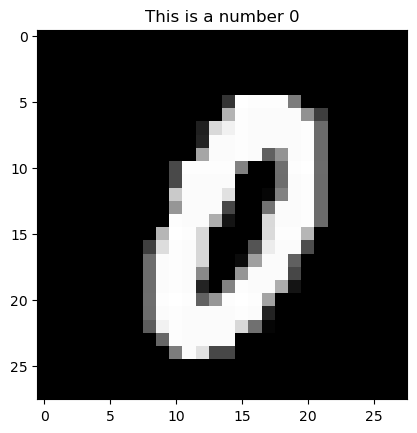

In [33]:
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"This is a number {label}")
plt.show()

# Calculation for the Input Layer

Concept: We are building a Linear (Feed-Forward) Network,

A Linear Layer consists of neurons in a single vertical line.

Our image is a square grid (28×28).

The Division: We must "cut" the image row by row and stack them into one long line.

The Calculation:

Height×Width=Total Input Features
28×28=784
So, our Input Layer must have 784 neurons.

In [35]:
img, label = training_data[1]

In [37]:
img.squeeze().shape

torch.Size([28, 28])

## The Architecture (1 Input, 1 Hidden, 1 Output
The Concept: We will build the simplest standard network.

Input Layer (784): Receives the pixels.

Hidden Layer (128): The "brain" that learns shapes (loops, lines). We pick 128 because it's enough to learn but not too big.

Output Layer (10): The final decision. We have 10 digits (0-9), so we need 10 output scores.

In [47]:
import torch.nn as nn

In [51]:
class SimpleNet(nn.Module) :
    def __init__(self) :
        super().__init__()
        self.flatten = nn.Flatten()

        self.layers = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),               # Actiovation.
            nn.Linear(128, 10)
        )

    def forward(self, x ) :
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

model = SimpleNet()
print(model)

SimpleNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Understanding Batch Size (The Stack)

The Concept: Think of the model like a teacher grading exams.

Batch Size = 1: The teacher grades 1 exam, updates the grade book, then picks up the next exam. (Too slow).

Batch Size = 64: The teacher picks up a stack of 64 exams, grades them all at once, and updates the grade book one time for the whole stack. (Much faster).

We use DataLoader to create these "stacks" for us.

In [59]:
from torch.utils.data import DataLoader

# Create stacks
 # here we divide the  data by the batch size cause we are gone pass the data in batches.
train_loader = DataLoader(training_data, batch_size=64, shuffle=True)    
# do for Test_data
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)

print(len(train_loader),"--",len(test_loader))


938 -- 157


## The Training Loop

In [61]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [63]:
def train() :
    model.train()

    for batch_No, ( data, target ) in enumerate( train_loader ) :

        output = model(data)

        loss = loss_fn( output, target )

        # Backpropogation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


In [65]:
train()

Test Accuracy: 94.6%
